<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO01/HO01_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HO01 João



# Relatório de Análise: Normalização de Textos (BBC News)

## 1. Visão Geral do Pipeline
O processo de normalização aplicado utilizou técnicas avançadas de Processamento de Linguagem Natural (PLN) para converter o texto bruto em uma forma estruturada adequada para análise:
* **Case Folding:** Padronização para minúsculas para evitar duplicidade de tokens.
* **Limpeza:** Remoção de pontuação e caracteres especiais.
* **Lematização com WordNet:** Diferente do Stemming (que apenas corta sufixos), a lematização utilizou as classes gramaticais (POS tags) para retornar as palavras à sua base semântica real (ex: 'are' e 'be' -> 'be').

## 2. Análise dos Resultados por Categoria
Ao observar as Word Clouds e as amostras processadas, notamos padrões distintos:

*   **Business:** Termos como 'firm', 'bank', 'growth' e 'market' são predominantes, indicando que o lematizador manteve a semântica de substantivos de mercado.
*   **Tech:** Vocabulário focado em 'mobile', 'software', 'technology' e 'user'. A lematização ajudou a agrupar variações de termos técnicos.
*   **Politics:** Termos como 'party', 'minister', 'government' e 'election' definem bem o corpus.

## 3. Observações sobre Stopwords e Ruído
Um ponto crítico identificado na análise visual é a alta frequência de palavras funcionais como **'be', 'have', 'say', 'not', 'but'**.
*   **Impacto:** Embora a lematização tenha funcionado perfeitamente (unindo 'is/are/was' em 'be'), essas palavras aparecem com destaque nas nuvens por serem muito comuns na língua inglesa.
*   **Recomendação:** Para uma análise de tópicos mais precisa, o próximo passo ideal seria a **remoção de Stopwords**, permitindo que termos específicos de cada categoria (como 'economy' ou 'gadget') ganhem mais relevância visual e estatística.

## 4. Conclusão
O pipeline de normalização foi bem-sucedido em reduzir a dimensionalidade do vocabulário mantendo o significado morfológico. Os textos agora estão prontos para tarefas de modelagem, como classificação automática de documentos ou análise de similaridade, após uma etapa adicional de filtragem de termos irrelevantes.

In [1]:
import requests

# URL do arquivo CSV no GitHub - POR FAVOR, ATUALIZE ESTA URL COM A CORRETA PARA O SEU ARQUIVO BBCNews.csv
github_csv_url = "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/refs/heads/main/HO01/BBCNews.csv"
local_csv_path = "/tmp/BBCNews.csv" # Salva o arquivo CSV em um caminho temporário

print(f"Tentando baixar o arquivo do GitHub: {github_csv_url}")

try:
    response = requests.get(github_csv_url)
    response.raise_for_status() # Levanta um HTTPError para respostas de status de erro (4xx ou 5xx)

    with open(local_csv_path, 'wb') as f:
        f.write(response.content)
    print(f"Arquivo baixado e salvo localmente em: {local_csv_path}\n")

except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar o arquivo: {e}")
    print("Por favor, verifique se a URL do GitHub está correta e o arquivo existe.")

Tentando baixar o arquivo do GitHub: https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/refs/heads/main/HO01/BBCNews.csv
Arquivo baixado e salvo localmente em: /tmp/BBCNews.csv



In [2]:
import os
# Este célula pode ser usado para verificar a existência do arquivo.
if os.path.exists('/tmp/BBCNews.csv'):
    print(f"Arquivo BBCNews.csv encontrado em: /tmp/BBCNews.csv")
else:
    print(f"Arquivo BBCNews.csv NÃO encontrado em: /tmp/BBCNews.csv. Verifique o download.")

Arquivo BBCNews.csv encontrado em: /tmp/BBCNews.csv


In [3]:
import pandas as pd

# Agora o arquivo é lido diretamente do caminho temporário onde foi baixado do GitHub
df = pd.read_csv('/tmp/BBCNews.csv')
display(df.head())

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [4]:
import nltk
import re
import string
from nltk.corpus import wordnet # Added for WordNetLemmatizer POS conversion

In [5]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab') # Ensuring punkt_tab is downloaded
nltk.download('averaged_perceptron_tagger_eng') # Explicitly adding download for the English tagger

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [6]:
from nltk.stem import WordNetLemmatizer # Changed to WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet # Import for WordNet POS mapping

# Helper function to convert NLTK POS tags to WordNet POS tags for lemmatization
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    if treebank_tag.startswith('V'): return wordnet.VERB
    if treebank_tag.startswith('N'): return wordnet.NOUN
    if treebank_tag.startswith('R'): return wordnet.ADV
    return None

def PipelineNormalizacao(text_string):
    #  Case Folding
    text_string = text_string.lower()


    #  Tratamento de pontuação
    # Remove all punctuation using string.punctuation
    text_string = text_string.translate(str.maketrans('', '', string.punctuation))
    # Remove extra spaces created by punctuation removal
    text_string = re.sub(r'\s+', ' ', text_string).strip()

    #  Tokenize and Tagging (Part-of-Speech Tagging)
    words_for_processing = word_tokenize(text_string, language='english') # Specify English
    tagged_words = pos_tag(words_for_processing) # Default to English tagging

    #  Lemmatization (using WordNetLemmatizer instead of RSLPStemmer)
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = []
    for word, tag in tagged_words:
        wn_tag = get_wordnet_pos(tag)
        if wn_tag: # Lemmatize with specific POS if available
            lemmatized_tokens.append(lemmatizer.lemmatize(word, wn_tag))
        else: # Otherwise, lemmatize without a specific POS
            lemmatized_tokens.append(lemmatizer.lemmatize(word))

    #  Tokenize o texto (final tokenization after all transformations)
    # The lemmatized_tokens list is already tokenized.
    return lemmatized_tokens, tagged_words

In [7]:
example_text = "There are several problems that must be addressed to process text, such as symbol segmentation and removal, and term transformation. In this notebook, one present approaches to address the most usual problems. Documents are information items that represent thoughts. Text documents are usually composed by sentences, i.e., logically linked sequence of words (or terms) and punctuation characters."

stemmed_tokens, tagged_tokens = PipelineNormalizacao(example_text)

print("Original text:", example_text)
print("\nTagged tokens:", tagged_tokens)
print("\nLemmatized and Tokenized text:", stemmed_tokens) # Changed 'Stemmed' to 'Lemmatized'

Original text: There are several problems that must be addressed to process text, such as symbol segmentation and removal, and term transformation. In this notebook, one present approaches to address the most usual problems. Documents are information items that represent thoughts. Text documents are usually composed by sentences, i.e., logically linked sequence of words (or terms) and punctuation characters.

Tagged tokens: [('there', 'EX'), ('are', 'VBP'), ('several', 'JJ'), ('problems', 'NNS'), ('that', 'WDT'), ('must', 'MD'), ('be', 'VB'), ('addressed', 'VBN'), ('to', 'TO'), ('process', 'VB'), ('text', 'NN'), ('such', 'JJ'), ('as', 'IN'), ('symbol', 'NN'), ('segmentation', 'NN'), ('and', 'CC'), ('removal', 'NN'), ('and', 'CC'), ('term', 'NN'), ('transformation', 'NN'), ('in', 'IN'), ('this', 'DT'), ('notebook', 'NN'), ('one', 'CD'), ('present', 'NN'), ('approaches', 'VBZ'), ('to', 'TO'), ('address', 'VB'), ('the', 'DT'), ('most', 'RBS'), ('usual', 'JJ'), ('problems', 'NNS'), ('docum

In [8]:
processed_texts_by_category = {}

# Iterate through each row of the DataFrame
for index, row in df.iterrows():
    text = row['Text']
    category = row['Category']

    # Process the text using the PipelineNormalizacao function
    lemmatized_tokens, _ = PipelineNormalizacao(text)

    # Store the lemmatized tokens in the dictionary, grouped by category
    if category not in processed_texts_by_category:
        processed_texts_by_category[category] = []
    processed_texts_by_category[category].append(lemmatized_tokens)

# Display the first few entries of the resulting dictionary to verify
for category, texts in list(processed_texts_by_category.items())[:3]:
    print(f"Category: {category}")
    print(f"  First processed text: {texts[0][:20]}...") # Display first 20 tokens
    print(f"  Number of texts in this category: {len(texts)}")
    print("\n")

Category: business
  First processed text: ['worldcom', 'exboss', 'launch', 'defence', 'lawyer', 'defend', 'former', 'worldcom', 'chief', 'bernie', 'ebbers', 'against', 'a', 'battery', 'of', 'fraud', 'charge', 'have', 'call', 'a']...
  Number of texts in this category: 336


Category: tech
  First processed text: ['lifestyle', 'governs', 'mobile', 'choice', 'faster', 'well', 'or', 'funky', 'hardware', 'alone', 'be', 'not', 'go', 'to', 'help', 'phone', 'firm', 'sell', 'more', 'handset']...
  Number of texts in this category: 261


Category: politics
  First processed text: ['howard', 'truanted', 'to', 'play', 'snooker', 'conservative', 'leader', 'michael', 'howard', 'have', 'admit', 'he', 'use', 'to', 'play', 'truant', 'to', 'spend', 'time', 'with']...
  Number of texts in this category: 274




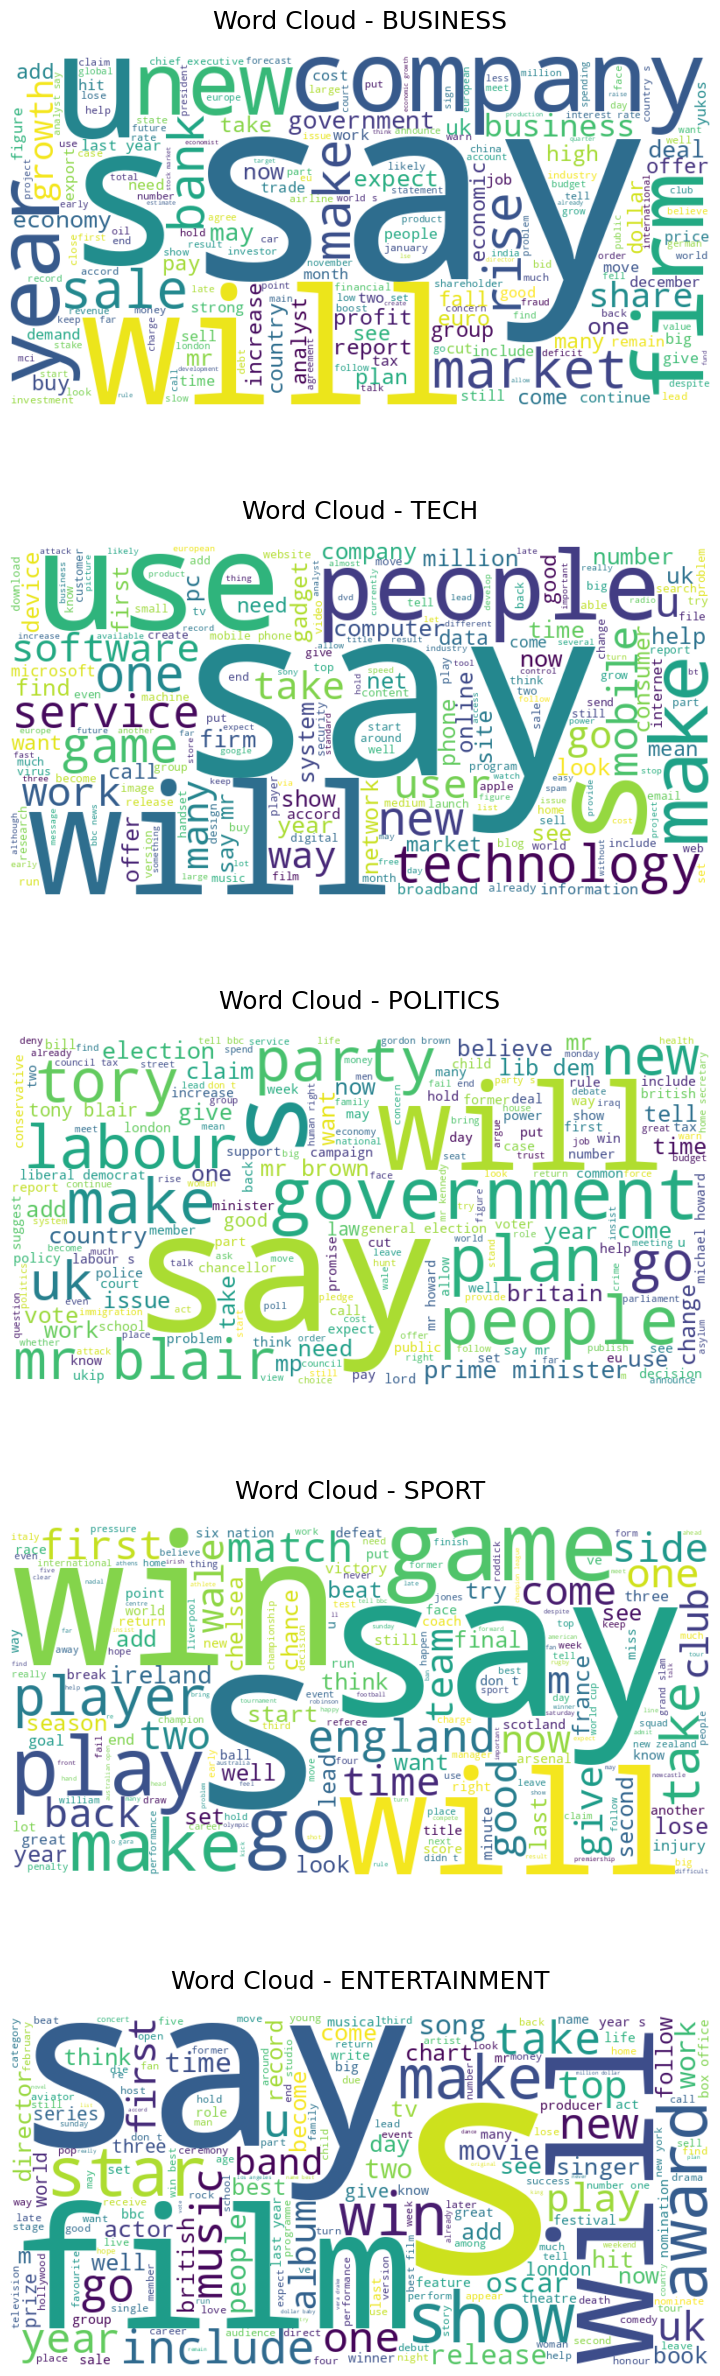

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordclouds(processed_data):
    categories = list(processed_data.keys())
    num_categories = len(categories)

    # Increased the figure size and vertical spacing
    fig, axes = plt.subplots(num_categories, 1, figsize=(10, 6 * num_categories))

    if num_categories == 1:
        axes = [axes]

    for i, category in enumerate(categories):
        # Flatten the list of tokens for the category into a single string
        all_tokens = [token for text_list in processed_data[category] for token in text_list]
        text_for_cloud = ' '.join(all_tokens)

        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_cloud)

        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'Word Cloud - {category.upper()}', fontsize=18, pad=20)
        axes[i].axis('off')

    # Adjusting space between subplots
    plt.subplots_adjust(hspace=0.4)
    plt.show()

# Generate and display the word clouds with better spacing
generate_wordclouds(processed_texts_by_category)